<a href="https://colab.research.google.com/github/Optoed/my-own-tolkien-generative-model/blob/main/my_generative_model_tolkien.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Это будет запоминающееся ДЗ, в котором вы будете строить свою собственную генеративную языковую модель. Она сможет даже продолжить главу во Властелине Колец, если наберётесь терпения при тренировке.

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import torch
from torch import nn
import random
from collections import Counter
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
import re  # для токенизатора с большим алфавитом
import os  # для работы с файлами чекпоинтов

In [ ]:
class CharARDataset(torch.utils.data.Dataset):
    """ Trivial dataset returning samples of fixed size cut from text position specified by idx """
    def __init__(self, filenames, sample_len):
        self.sample_len = sample_len
        self.texts = []
        for filename in filenames:
            with open(filename, 'r', encoding='utf-8') as f:
                self.texts.append(f.read())
        self.raw_text = "\n#\n".join(self.texts)

        prev_len = None
        while True:
            self.raw_text = self.raw_text.replace('  ', ' ')
            if len(self.raw_text) == prev_len:
                break
            prev_len = len(self.raw_text)

        cnt = Counter(self.raw_text)
        self.mapping = dict(zip(sorted(cnt.keys()), range(len(cnt))))
        self.alphabet = list(self.mapping)
        self.tokens = self.tokenize(self.raw_text)

    def cuda(self):
        self.tokens = self.tokens.cuda()

    def __len__(self):
        return (len(self.raw_text) - self.sample_len - 1)

    def tokenize(self, text, convert_to_one_hot=False):
        tokens = torch.tensor(list(map(self.mapping.get, text)))# TODO 1. Convert text to tokens
        if convert_to_one_hot:
            tokens =  torch.nn.functional.one_hot(tokens, len(self.alphabet))
        return tokens

    def __getitem__(self, idx):
        source = self.tokens[idx: idx + self.sample_len]
        target = self.tokens[idx+1: idx + self.sample_len+1]

        return {"input": source,
                "target": target,
               }


In [ ]:
class WordARDataset(torch.utils.data.Dataset):
    """Авторегрессионный датасет по словам (более крупный алфавит, чем посимвольный)."""
    def __init__(self, filenames, sample_len):
        self.sample_len = sample_len
        self.texts = []
        for filename in filenames:
            with open(filename, 'r', encoding='utf-8') as f:
                self.texts.append(f.read())
        self.raw_text = "\n#\n".join(self.texts)

        prev_len = None
        while True:
            self.raw_text = self.raw_text.replace('  ', ' ')
            if len(self.raw_text) == prev_len:
                break
            prev_len = len(self.raw_text)

        # Токенизируем на слова/знаки препинания
        self.tokens_text = self._tokenize_text(self.raw_text)
        cnt = Counter(self.tokens_text)
        # Словарь: token -> id
        self.mapping = {tok: idx for idx, (tok, _) in enumerate(cnt.most_common())}
        self.alphabet = list(self.mapping.keys())

        # Цифровые id всех токенов корпуса
        self.tokens = self.tokenize(self.tokens_text)

    def _tokenize_text(self, text: str):
        """Простейший токенизатор: слова и знаки препинания как отдельные токены."""
        return re.findall(r"\w+|[^\w\s]", text, flags=re.UNICODE)

    def __len__(self):
        return len(self.tokens) - self.sample_len - 1

    def tokenize(self, text_or_tokens, convert_to_one_hot: bool = False):
        """Преобразует строку ИЛИ список токенов в последовательность id."""
        if isinstance(text_or_tokens, str):
            tokens_list = self._tokenize_text(text_or_tokens)
        else:
            tokens_list = list(text_or_tokens)

        ids = torch.tensor([self.mapping.get(tok, 0) for tok in tokens_list], dtype=torch.long)
        if convert_to_one_hot:
            ids = torch.nn.functional.one_hot(ids, len(self.alphabet))
        return ids

    def __getitem__(self, idx):
        source = self.tokens[idx: idx + self.sample_len]
        target = self.tokens[idx + 1: idx + self.sample_len + 1]
        return {"input": source, "target": target}


In [ ]:
ds = CharARDataset(['books/lord_of_the_rings.puncto.txt'], sample_len=200)
dl = DataLoader(ds, batch_size=64, shuffle=True, num_workers=0)

In [ ]:
for b in tqdm(dl):
    pass

  0%|          | 0/39226 [00:00<?, ?it/s]

In [ ]:
criterion = nn.CrossEntropyLoss() # TODO 2. create cross entropy
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
class LSTMEmbPredictor(nn.Module):
    def __init__(self, n_inp: int, inp_dim: int, hidden_dim: int, n_out: int, layers: int, dropout: int=0):
        super().__init__()
        #######
        # n_inp - количество различных токенов
        # inp_dim - размерность эмбеддинга, который кодирует токены на входе в сеть
        # hidden_dim - размерность внутри сети
        # n_out - количество выхолных токенов. Раз у нас авторегрессия, значит = n_inp
        # layers - количество внутренних слоёв
        self.meta_parameters = {'name': 'LSTMEmbPredictor',
                                'args': { 'n_inp': n_inp, 'inp_dim': inp_dim, 'hidden_dim': hidden_dim, 'n_out': n_out,
                                            'layers': layers, 'dropout':dropout }}

        self.emb = nn.Embedding(n_inp, inp_dim)
        self.layer = nn.LSTM(inp_dim, hidden_dim, layers, dropout=dropout, batch_first=True)
        self.conv = nn.Conv1d(hidden_dim, n_out, 1)

        self.h_n_c_n = None

    def forward(self, x, apply_last_lstm_memory=False, hidden=None):
        x = self.emb(x)
        if not apply_last_lstm_memory:
            self.h_n_c_n = None
        if hidden is not None:

            self.h_n_c_n = hidden

        x, self.h_n_c_n = self.layer(x, self.h_n_c_n)
        x = x.permute(0, 2, 1)  # Conv1d expects (batch, channels, seq_len) but LSTM outputs (batch, seq_len, channels)
        x = self.conv(x)
        if hidden is None:
            return x
        else:
            return x, self.h_n_c_n


In [ ]:
steps_per_epoch = 1000
epochs_count = 20
max_lr=1e-2
inp_dim=8
hidden=128
layers=3

# n_inp - that's power of out alphabet. Remember that number!
n_inp = len(ds.alphabet)
model_lstm = LSTMEmbPredictor(n_inp=n_inp, inp_dim=inp_dim, hidden_dim=hidden, n_out=n_inp, layers=layers, dropout=0)
model_lstm = model_lstm.to(device)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=max_lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer_lstm, max_lr=5e-3, epochs=epochs_count, steps_per_epoch=steps_per_epoch)

In [ ]:
def train_epoch(model, optimizer, criterion, train_dl, scheduler=None):
    model.train()

    loss_hist = []
    lr_hist = []
    for it, batch in enumerate(tqdm(train_dl, total=steps_per_epoch)):
        if it >= steps_per_epoch: break

        batch['input'] = batch['input'].to(device)
        batch['target'] = batch['target'].to(device)

        preds = model(batch['input'])
        # preds shape: (batch, n_out, seq_len), target shape: (batch, seq_len)
        # CrossEntropyLoss expects (batch, classes, ...) and (batch, ...)
        loss = criterion(preds, batch['target'])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if scheduler is not None: scheduler.step()

        loss_hist.append(loss.item())
        lr_hist.append(scheduler.get_last_lr()[0] if scheduler is not None else optimizer.param_groups[0]['lr'])

    return loss_hist, lr_hist

def train(epoch_num, model, optimizer, criterion, train_dl, scheduler=None):
    losses = []
    lrs = []
    for epoch in range(epoch_num):
        print(f"[{epoch}] epoch")
        loss_hist, lr_hist = train_epoch(model, optimizer, criterion, train_dl, scheduler)
        losses.extend(loss_hist)
        lrs.extend(lr_hist)

        clear_output()
        fig, ax1 = plt.subplots()

        color = 'tab:blue'
        ax1.set_xlabel('iteration')
        ax1.set_ylabel('loss', color=color)
        ax1.plot(losses, color=color)
        ax1.tick_params(axis='y', labelcolor=color)

        ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

        color = 'g'
        ax2.set_ylabel('lr', color=color)  # we already handled the x-label with ax1
        ax2.plot(lrs, color=color)
        ax2.tick_params(axis='y', labelcolor=color)

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        plt.show()

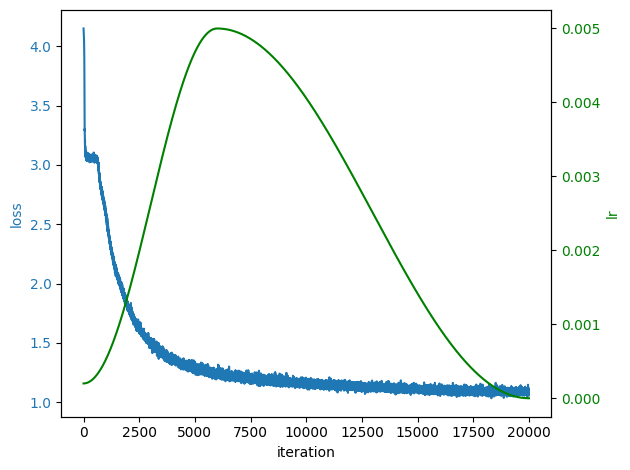

In [ ]:
train(epochs_count, model_lstm, optimizer_lstm, criterion, dl, scheduler)

In [ ]:
# функция infer с temperature sampling для предотвращения зацикливания
def infer(model, prefix, ds, generate_seq_len=20, temperature=0.8, top_k=50):
    """Генерация текста с поддержкой temperature sampling для избежания зацикливания.

    Args:
        model: обученная модель
        prefix: начальный текст для генерации
        ds: датасет (CharARDataset или WordARDataset)
        generate_seq_len: сколько токенов сгенерировать
        temperature: температура для sampling (0.8 = более детерминировано, >1.0 = более случайно)
        top_k: берём только top_k наиболее вероятных токенов (предотвращает зацикливание)
    """
    model.eval()
    with torch.no_grad():
        tokens = ds.tokenize(prefix)
        inp = tokens.unsqueeze(0).to(device)
        output = model(inp)

    generated_tokens = []
    for _ in range(generate_seq_len):
        # Берём последний шаг по времени
        last_step_logits = output[:, :, -1]  # shape: (batch, vocab_size)

        # Применяем temperature
        if temperature != 1.0:
            last_step_logits = last_step_logits / temperature

        # Top-k filtering для предотвращения зацикливания
        if top_k is not None and top_k < last_step_logits.size(1):
            top_k_logits, top_k_indices = torch.topk(last_step_logits, top_k, dim=1)
            # Создаём новый тензор с -inf для всех остальных токенов
            filtered_logits = torch.full_like(last_step_logits, float('-inf'))
            filtered_logits.scatter_(1, top_k_indices, top_k_logits)
            last_step_logits = filtered_logits

        # Softmax и sampling (вместо жадного argmax)
        probs = torch.softmax(last_step_logits, dim=1)
        last_ch_idx = torch.multinomial(probs, 1).item()

        token = ds.alphabet[last_ch_idx]
        generated_tokens.append(token)

        # Кормим в модель предсказанный токен, сохраняя скрытое состояние
        inp = torch.tensor([[last_ch_idx]], dtype=torch.long).to(device)
        output = model(inp, apply_last_lstm_memory=True)

    # Определяем, символьный или словарный датасет
    # Проверяем по типу класса и размеру алфавита
    is_char_dataset = False
    try:
        # Проверяем тип класса (самый надёжный способ)
        class_name = ds.__class__.__name__
        if 'Char' in class_name:
            is_char_dataset = True
        elif 'Word' in class_name:
            is_char_dataset = False
        else:
            # Если не можем определить по классу, проверяем по размеру алфавита
            vocab_size = len(ds.alphabet)
            # Символьные датасеты обычно имеют маленький алфавит (<200)
            # Словарные - большой (>1000)
            if vocab_size < 200:
                is_char_dataset = True
            elif vocab_size > 1000:
                is_char_dataset = False
            else:
                # Средний размер - проверяем по первому элементу
                if isinstance(ds.alphabet[0], str) and len(ds.alphabet[0]) == 1:
                    is_char_dataset = True
    except Exception as e:
        # Если всё не удалось, пробуем по размеру
        vocab_size = len(ds.alphabet) if hasattr(ds, 'alphabet') else 0
        is_char_dataset = vocab_size < 200

    if is_char_dataset:
        # Для символьного датасета просто склеиваем
        result = "".join(generated_tokens)
    else:
        # Для словарного датасета ВСЕГДА добавляем пробелы между токенами
        # Исключение: не добавляем пробел перед знаками препинания
        result_parts = []
        punctuation = set('.,!?;:()[]{}"\'')

        for i, token in enumerate(generated_tokens):
            # Добавляем пробел перед каждым токеном (кроме первого)
            if i > 0:
                # Пробел НЕ нужен только если текущий токен начинается с пунктуации
                # (знаки препинания должны быть без пробела перед ними)
                if len(token) > 0 and token[0] not in punctuation:
                    result_parts.append(' ')

            result_parts.append(token)

        result = "".join(result_parts)

    print(result)
    return result

In [ ]:
class GRUEmbPredictor(nn.Module):
    def __init__(self, n_inp: int, inp_dim: int, hidden_dim: int, n_out: int, layers: int, dropout: int=0):
        super().__init__()
        self.meta_parameters = {'name': 'GRUEmbPredictor',
                                'args': { 'n_inp': n_inp, 'inp_dim': inp_dim, 'hidden_dim': hidden_dim, 'n_out': n_out,
                                            'layers': layers, 'dropout':dropout }}

        self.emb = nn.Embedding(n_inp, inp_dim)
        self.layer = nn.GRU(inp_dim, hidden_dim, layers, dropout=dropout, batch_first=True)
        self.conv = nn.Conv1d(hidden_dim, n_out, 1)

        self.h_n = None

    def forward(self, x, apply_last_lstm_memory=False, hidden=None):
        x = self.emb(x)
        if not apply_last_lstm_memory:
            self.h_n = None
        if hidden is not None:
            self.h_n = hidden
        x, self.h_n = self.layer(x, self.h_n)
        x = x.permute(0, 2, 1)  # Conv1d expects (batch, channels, seq_len)
        x = self.conv(x)
        if hidden is None:
            return x
        else:
            return x, self.h_n

model_gru = GRUEmbPredictor(n_inp=n_inp, inp_dim=inp_dim, hidden_dim=hidden, n_out=n_inp, layers=layers, dropout=0)
model_gru = model_gru.to(device)
optimizer_gru = torch.optim.Adam(model_gru.parameters(), lr=max_lr)
scheduler_gru = torch.optim.lr_scheduler.OneCycleLR(optimizer_gru, max_lr=5e-3, epochs=epochs_count, steps_per_epoch=steps_per_epoch)

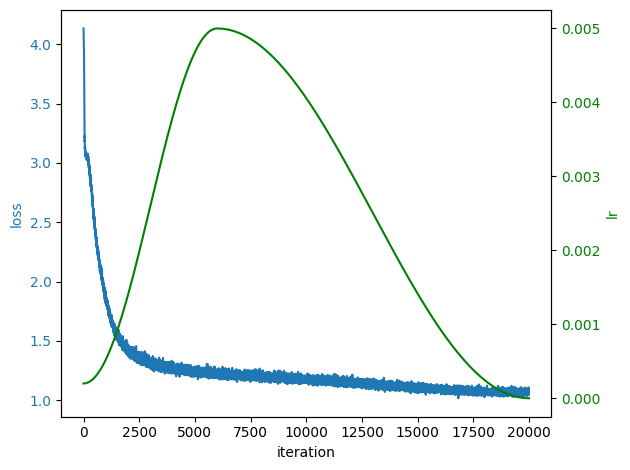

In [ ]:
train(epochs_count, model_gru, optimizer_gru, criterion, dl, scheduler_gru)

In [ ]:
infer(model_gru, "Boro", ds, 50)

mir was still all the stream that had been seen an


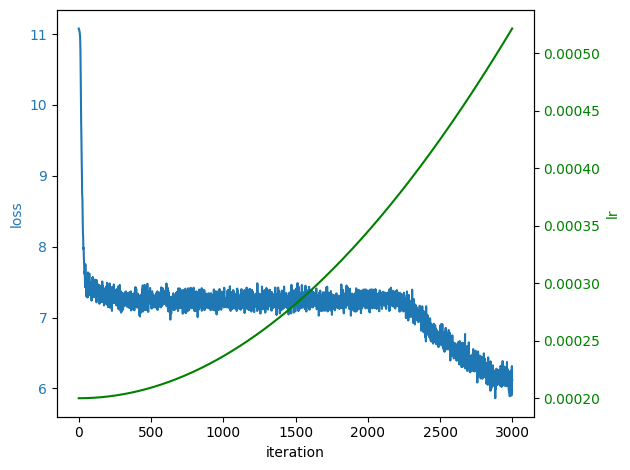

[3] epoch


  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Now make large clever model. Let it come up with some story about Smeagol and Boromir
steps_per_epoch_large = 2000
epochs_count_large = 30
max_lr_large = 1e-2
inp_dim_large = 32
hidden_large = 256
layers_large = 4

model_large = LSTMEmbPredictor(n_inp=n_inp, inp_dim=inp_dim_large, hidden_dim=hidden_large, n_out=n_inp, layers=layers_large, dropout=0.2)
model_large = model_large.to(device)
optimizer_large = torch.optim.Adam(model_large.parameters(), lr=max_lr_large)
scheduler_large = torch.optim.lr_scheduler.OneCycleLR(optimizer_large, max_lr=5e-3, epochs=epochs_count_large, steps_per_epoch=steps_per_epoch_large)

train(epochs_count_large, model_large, optimizer_large, criterion, dl, scheduler_large)

# Generate story about Smeagol and Boromir
infer(model_large, "Smeagol and Boromir", ds, 200)

In [ ]:
# УТИЛИТА: Исправление форматирования уже сгенерированного текста
def fix_word_spacing(text):
    """Добавляет пробелы между словами в склеенном тексте."""
    import re
    # Добавляем пробел перед заглавными буквами (начало слова)
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    # Добавляем пробел после знаков препинания, если его нет
    text = re.sub(r'([.,!?;:])([A-Za-z])', r'\1 \2', text)
    # Добавляем пробел перед знаками препинания, если его нет
    text = re.sub(r'([A-Za-z])([.,!?;:])', r'\1\2', text)
    return text

# Пример использования для вашего текста:
test_text = ".Theynotallbeaedge,andaland."
print("Исправленный текст:")
print(fix_word_spacing(test_text))

In [ ]:
# Генерируем текст в стиле Толкина
infer(model_large, "Smeagol and Boromir", ds_word, 200)

,andFrodototheblack-thedayandthedooroftheworld,buthadseehecome,andnotawhiletoahead.Iiswent,andtheirseen,andwillthemoment"Ityou"Itheyhadthemlike,swashadcomeandthelastandtheheartofthemountains.saidItheirthatalittle-had,intheother,.YoutheyFrodo."saidwasyouatthebeenofthedwarves,butwearethelittleoftheworldofadarkofthelandoftheendtoablack,andthiscouldallandtheawhile,andthegreatstream.Andsaidtothelandofthetreesofthewind;andthepathwiththeirgreatnight,."hetonothavehaveagreat,"Hego.Theywerestill,andtheyhavelongatime.Thehead""saidthey.IttheyhadadarkoftheWest."It,Iwilltheirlong;though


',andFrodototheblack-thedayandthedooroftheworld,buthadseehecome,andnotawhiletoahead.Iiswent,andtheirseen,andwillthemoment"Ityou"Itheyhadthemlike,swashadcomeandthelastandtheheartofthemountains.saidItheirthatalittle-had,intheother,.YoutheyFrodo."saidwasyouatthebeenofthedwarves,butwearethelittleoftheworldofadarkofthelandoftheendtoablack,andthiscouldallandtheawhile,andthegreatstream.Andsaidtothelandofthetreesofthewind;andthepathwiththeirgreatnight,."hetonothavehaveagreat,"Hego.Theywerestill,andtheyhavelongatime.Thehead""saidthey.IttheyhadadarkoftheWest."It,Iwilltheirlong;though'

In [ ]:
# add spaces
# Генерируем текст в стиле Толкина
infer(model_large, "Smeagol and Boromir", ds_word, 200)

.Theynotallbeaedge,andaland."TheShire""""And,""swasnothislittle,Butasthegreatlightfortheground.Thewindwilllong."SoandnottotoinwashisRing,"IMerry.IFrodoadarklikeofcomeandthegroundandtheblack;andtheynotwerehadgoneasinthehobbits;andhenotno."hesaid,andheyoutobeenthattoit,andsaidonhecouldthelittle.HetheolddarkawindandgoneandthedwarvesandhavebeandaShirethegoodofthehobbitsofthedoor,andtheyintheyme,andnotaeyesofthelittlelong."Theblackoftheirground.Ihadhislast,andthathadtheheadofthegreatwindofthefewofthedoor.hedowerenottotheyhetheirtimeandthedarkandthegreatend.Ittheythatheyou


'.Theynotallbeaedge,andaland."TheShire""""And,""swasnothislittle,Butasthegreatlightfortheground.Thewindwilllong."SoandnottotoinwashisRing,"IMerry.IFrodoadarklikeofcomeandthegroundandtheblack;andtheynotwerehadgoneasinthehobbits;andhenotno."hesaid,andheyoutobeenthattoit,andsaidonhecouldthelittle.HetheolddarkawindandgoneandthedwarvesandhavebeandaShirethegoodofthehobbitsofthedoor,andtheyintheyme,andnotaeyesofthelittlelong."Theblackoftheirground.Ihadhislast,andthathadtheheadofthegreatwindofthefewofthedoor.hedowerenottotheyhetheirtimeandthedarkandthegreatend.Ittheythatheyou'

In [ ]:
# add spaces
# Генерируем текст в стиле Толкина
infer(model_large, "Smeagol and Boromir", ds_word, 200)

there,"Buttheyhadakingofthegreatofthemomentthatthedwarves."said"""Iall,HeIwastheirtimetohavebetoabeenofthemountainsandthewindoftheking.Ihavebeenwasaowndoorandall."heGandalf."sGimli.But""asifweseenothavenothaditorthat""saidmust,""heFrodo.And.Iwouldthehead."theyagreatRingofthedaythegreatvoice,"Sothetime.hewent,hehavenotofatreesandgowiththeend-highandbeseeyouit."saidIwilltheythetrees,itIamoftheRing,andthefirstdarkthatthegreatway.shadthebeendaytotheMountain,andthetimeoftheoldwerethewhile."Andyouthehandandcouldattheheartoftheownofthelandtheythewindinthegreat


'there,"Buttheyhadakingofthegreatofthemomentthatthedwarves."said"""Iall,HeIwastheirtimetohavebetoabeenofthemountainsandthewindoftheking.Ihavebeenwasaowndoorandall."heGandalf."sGimli.But""asifweseenothavenothaditorthat""saidmust,""heFrodo.And.Iwouldthehead."theyagreatRingofthedaythegreatvoice,"Sothetime.hewent,hehavenotofatreesandgowiththeend-highandbeseeyouit."saidIwilltheythetrees,itIamoftheRing,andthefirstdarkthatthegreatway.shadthebeendaytotheMountain,andthetimeoftheoldwerethewhile."Andyouthehandandcouldattheheartoftheownofthelandtheythewindinthegreat'

In [ ]:
infer(model_large, "Smeagol and Boromir", ds_word, 200, temperature=0.8, top_k=50)

that his own road. but don" said have is they a little voice. If I went was was you."" And they there he"" said the time he the king," he he the been, and even the great black in the trees from was dark to the few." We said;"" The last came up as a long while and the own, at all I see, and we not them a shadow of the great." All what all and see was see to the mountains of a shadow, the king, and I did him they that a great was it, with and not all." t what all, and all did had the king that all would been had be a night, but it do the dark a day and be more,"" I thought of had the sword, He they he the king and your their air of the own of the Shire." They all the dwarves was go now. We have me a dark - grey of the


'that his own road. but don" said have is they a little voice. If I went was was you."" And they there he"" said the time he the king," he he the been, and even the great black in the trees from was dark to the few." We said;"" The last came up as a long while and the own, at all I see, and we not them a shadow of the great." All what all and see was see to the mountains of a shadow, the king, and I did him they that a great was it, with and not all." t what all, and all did had the king that all would been had be a night, but it do the dark a day and be more,"" I thought of had the sword, He they he the king and your their air of the own of the Shire." They all the dwarves was go now. We have me a dark - grey of the'